# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The AI Impact on Jobs and Layoffs Dataset](https://www.kaggle.com/datasets/shivasingh4945/ai-impact-on-jobs-and-layoff-risk-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier

/kaggle/input/datasets/shivasingh4945/ai-impact-on-jobs-and-layoff-risk-dataset/ai-impact-jobs-layoff-risk-dataset.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('ai-impact-jobs-layoff-risk-dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


## last Five row

In [4]:
df.tail()

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
19995,56,Bachelor's,10,Retail,Sales Associate,Small,Entry,29,62,44,Low,0,4,16,0,Medium
19996,43,Bachelor's,9,Manufacturing,Production Supervisor,Medium,Entry,87,20,20,High,9,23,77,67,High
19997,28,High School,7,Telecom,Support Specialist,Medium,Entry,91,2,49,Medium,2,14,55,10,High
19998,46,Bachelor's,3,Manufacturing,Quality Engineer,Medium,Senior,76,40,89,Medium,3,13,66,5,Medium
19999,36,Bachelor's,5,Retail,Store Manager,Medium,Mid,45,65,75,Low,1,0,30,8,Medium


## Shape of our dataset

In [5]:
df.shape

(20000, 16)

## List out all columns

In [6]:
df.columns

Index(['Age', 'Education_Level', 'Years_of_Experience', 'Industry', 'Job_Role',
       'Company_Size', 'Job_Level', 'Routine_Task_Percentage',
       'Creativity_Requirement', 'Human_Interaction_Level',
       'AI_Adoption_Level', 'Number_of_AI_Tools_Used',
       'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage',
       'AI_Training_Hours', 'Layoff_Risk'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Age                            int64
Education_Level               object
Years_of_Experience            int64
Industry                      object
Job_Role                      object
Company_Size                  object
Job_Level                     object
Routine_Task_Percentage        int64
Creativity_Requirement         int64
Human_Interaction_Level        int64
AI_Adoption_Level             object
Number_of_AI_Tools_Used        int64
AI_Usage_Hours_Per_Week        int64
Tasks_Automated_Percentage     int64
AI_Training_Hours              int64
Layoff_Risk                   object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         20000 non-null  int64 
 1   Education_Level             20000 non-null  object
 2   Years_of_Experience         20000 non-null  int64 
 3   Industry                    20000 non-null  object
 4   Job_Role                    20000 non-null  object
 5   Company_Size                20000 non-null  object
 6   Job_Level                   20000 non-null  object
 7   Routine_Task_Percentage     20000 non-null  int64 
 8   Creativity_Requirement      20000 non-null  int64 
 9   Human_Interaction_Level     20000 non-null  int64 
 10  AI_Adoption_Level           20000 non-null  object
 11  Number_of_AI_Tools_Used     20000 non-null  int64 
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64 
 13  Tasks_Automated_Percentage  20000 non-null  in

## Check Null Value

In [9]:
df.isnull().sum()

Age                           0
Education_Level               0
Years_of_Experience           0
Industry                      0
Job_Role                      0
Company_Size                  0
Job_Level                     0
Routine_Task_Percentage       0
Creativity_Requirement        0
Human_Interaction_Level       0
AI_Adoption_Level             0
Number_of_AI_Tools_Used       0
AI_Usage_Hours_Per_Week       0
Tasks_Automated_Percentage    0
AI_Training_Hours             0
Layoff_Risk                   0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.00000,20000.000000
mean,40.361500,7.265500,51.885500,47.786700,60.055000,2.460350,6.77395,37.22895,12.621400
std,11.526333,4.720606,24.437808,26.100482,22.267801,2.097486,6.08637,19.99512,13.552647
min,21.000000,0.000000,10.000000,0.000000,20.000000,0.000000,0.00000,4.00000,0.000000
25%,30.000000,4.000000,31.000000,27.000000,41.000000,1.000000,2.00000,21.00000,4.000000
50%,40.000000,7.000000,52.000000,48.000000,62.000000,2.000000,5.00000,35.00000,8.000000
75%,50.000000,11.000000,73.000000,69.000000,79.000000,4.000000,10.00000,51.00000,18.000000
max,60.000000,32.000000,94.000000,100.000000,99.000000,10.000000,30.00000,93.00000,79.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

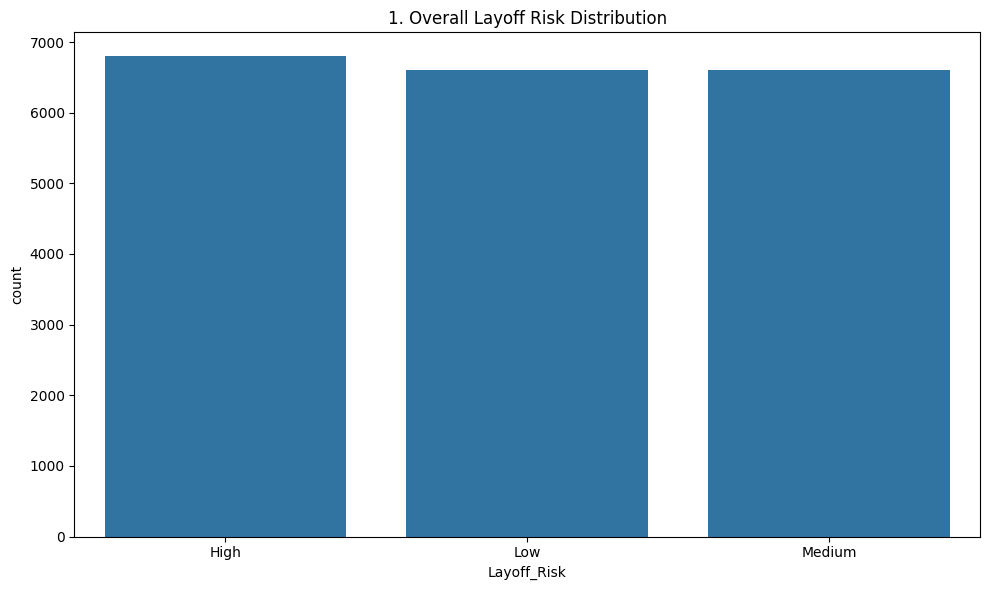

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Layoff_Risk', order=df['Layoff_Risk'].value_counts().index)
plt.title(f'{plot_no}. Overall Layoff Risk Distribution')
show_fig()
plot_no += 1

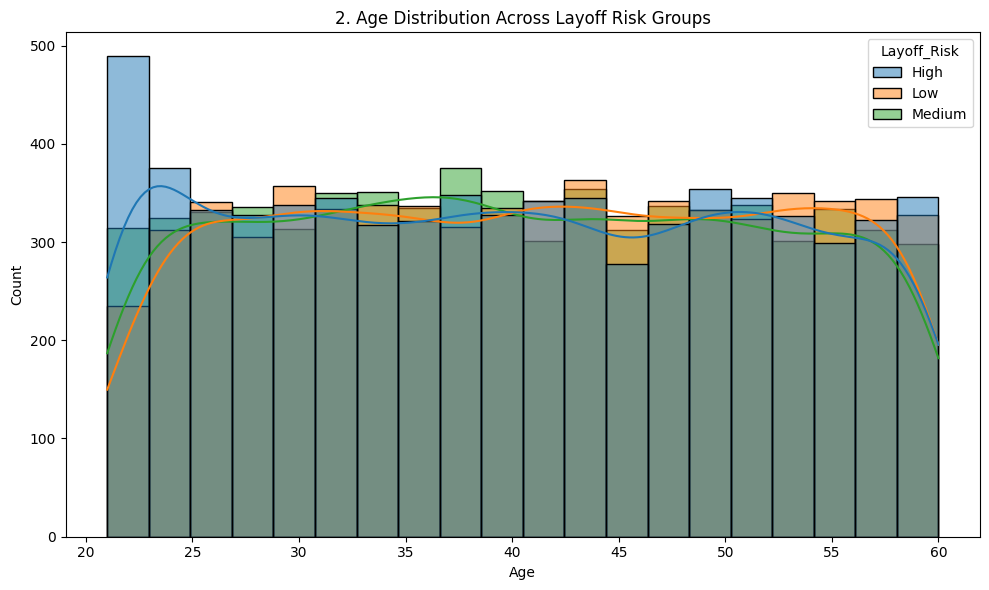

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue='Layoff_Risk', kde=True, bins=20)
plt.title(f'{plot_no}. Age Distribution Across Layoff Risk Groups')
show_fig()
plot_no += 1

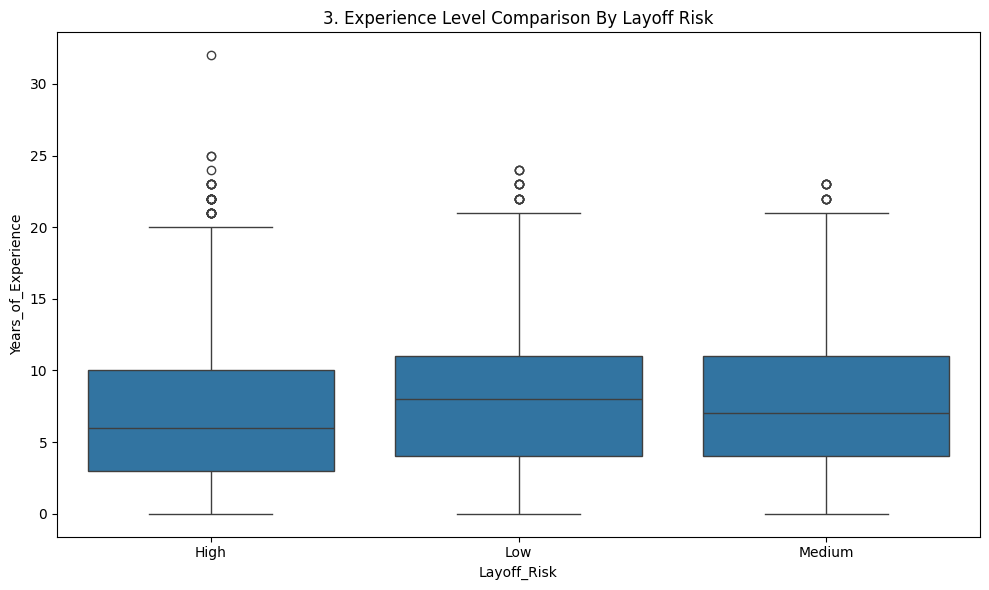

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Layoff_Risk', y='Years_of_Experience')
plt.title(f'{plot_no}. Experience Level Comparison By Layoff Risk')
show_fig()
plot_no += 1

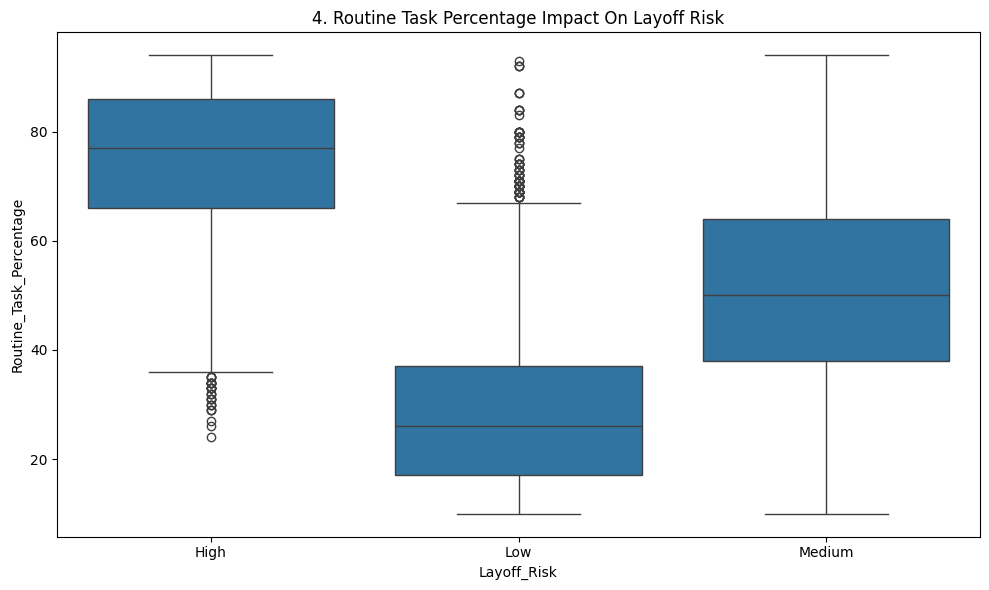

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Layoff_Risk', y='Routine_Task_Percentage')
plt.title(f'{plot_no}. Routine Task Percentage Impact On Layoff Risk')
show_fig()
plot_no += 1

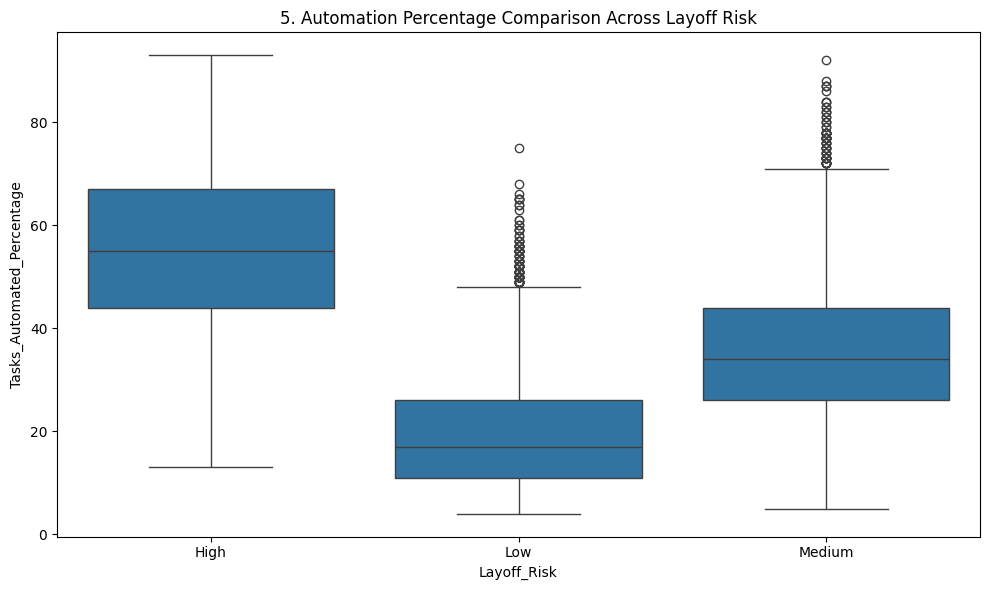

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Layoff_Risk', y='Tasks_Automated_Percentage')
plt.title(f'{plot_no}. Automation Percentage Comparison Across Layoff Risk')
show_fig()
plot_no += 1

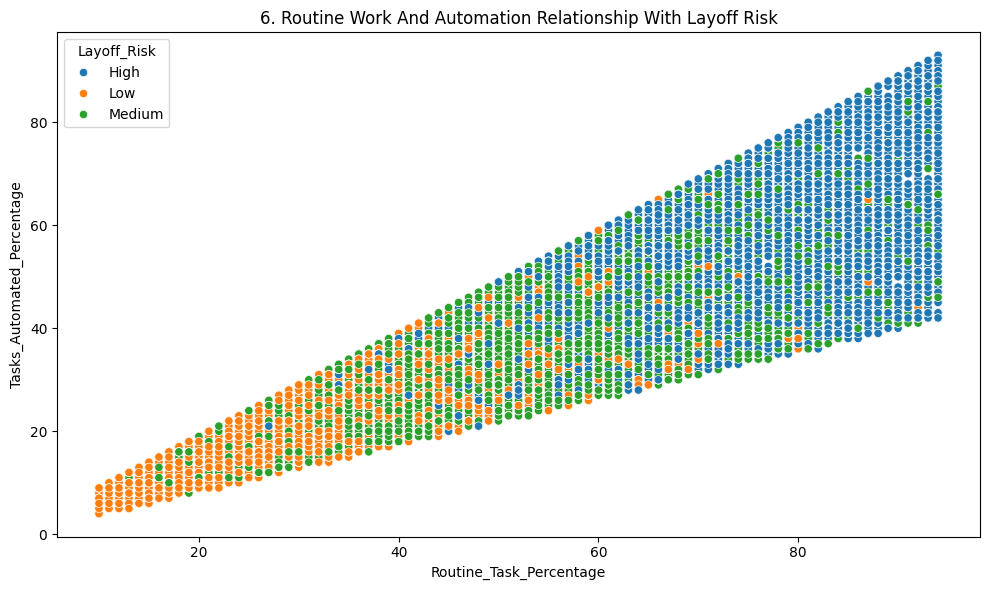

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Routine_Task_Percentage', y='Tasks_Automated_Percentage', hue='Layoff_Risk')
plt.title(f'{plot_no}. Routine Work And Automation Relationship With Layoff Risk')
show_fig()
plot_no += 1

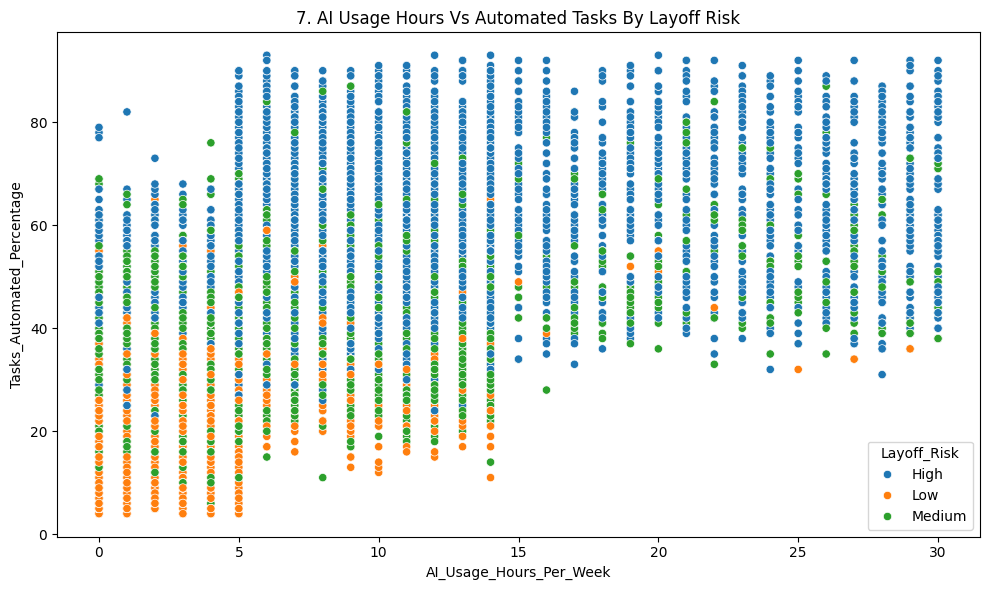

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='AI_Usage_Hours_Per_Week', y='Tasks_Automated_Percentage', hue='Layoff_Risk')
plt.title(f'{plot_no}. AI Usage Hours Vs Automated Tasks By Layoff Risk')
show_fig()
plot_no += 1

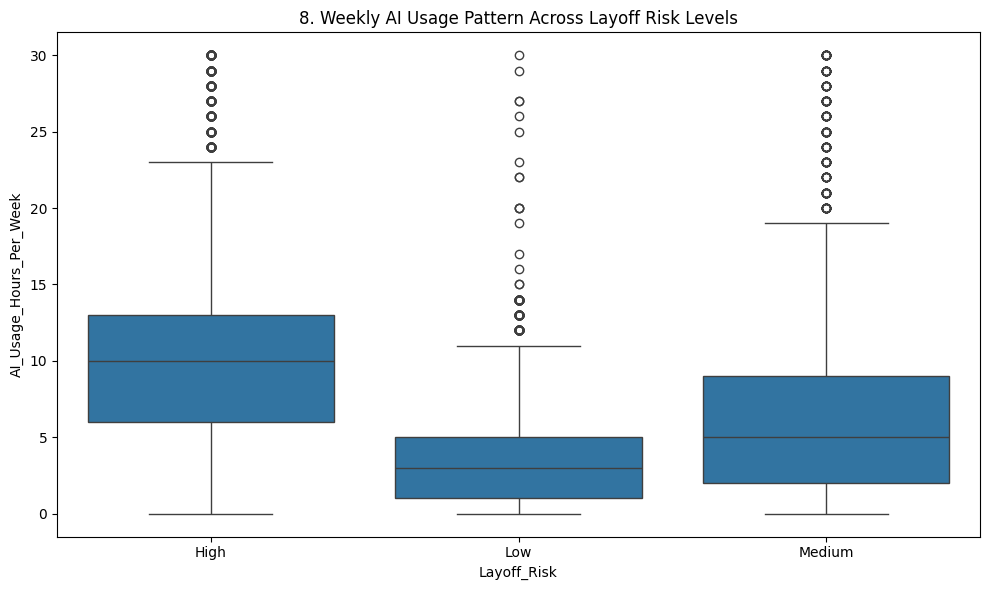

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Layoff_Risk', y='AI_Usage_Hours_Per_Week')
plt.title(f'{plot_no}. Weekly AI Usage Pattern Across Layoff Risk Levels')
show_fig()
plot_no += 1

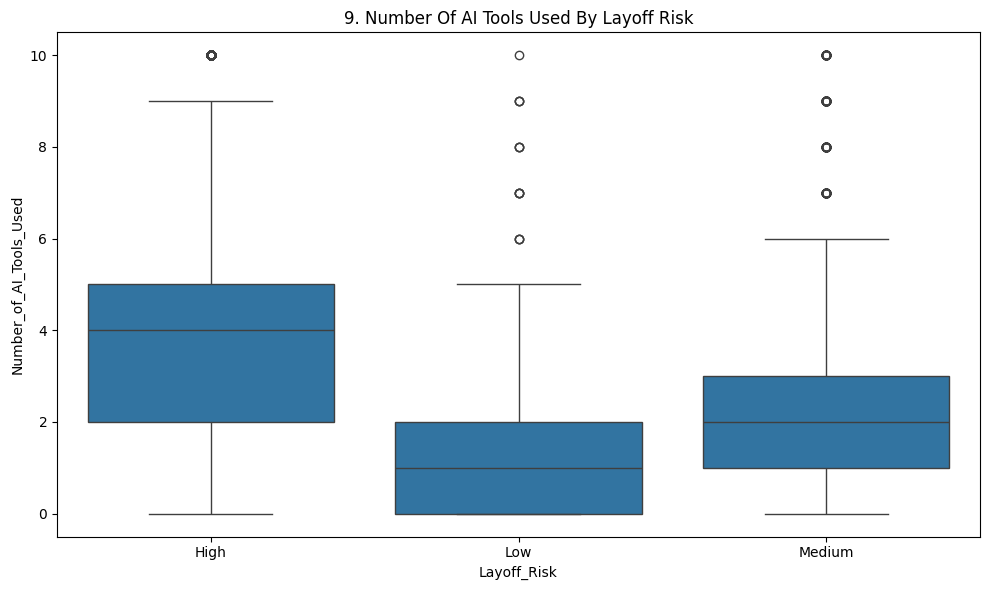

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Layoff_Risk', y='Number_of_AI_Tools_Used')
plt.title(f'{plot_no}. Number Of AI Tools Used By Layoff Risk')
show_fig()
plot_no += 1

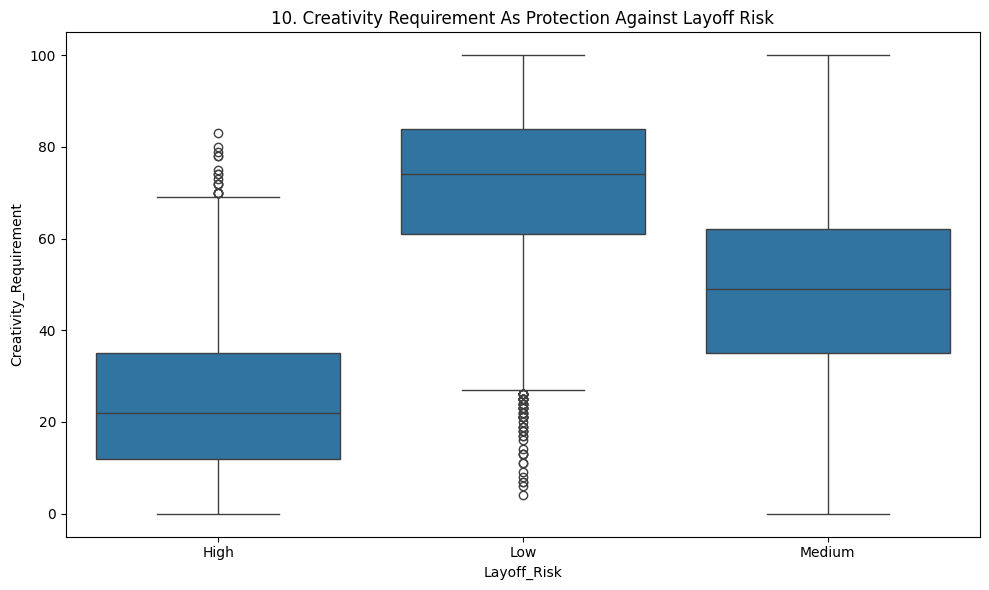

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Layoff_Risk', y='Creativity_Requirement')
plt.title(f'{plot_no}. Creativity Requirement As Protection Against Layoff Risk')
show_fig()
plot_no += 1

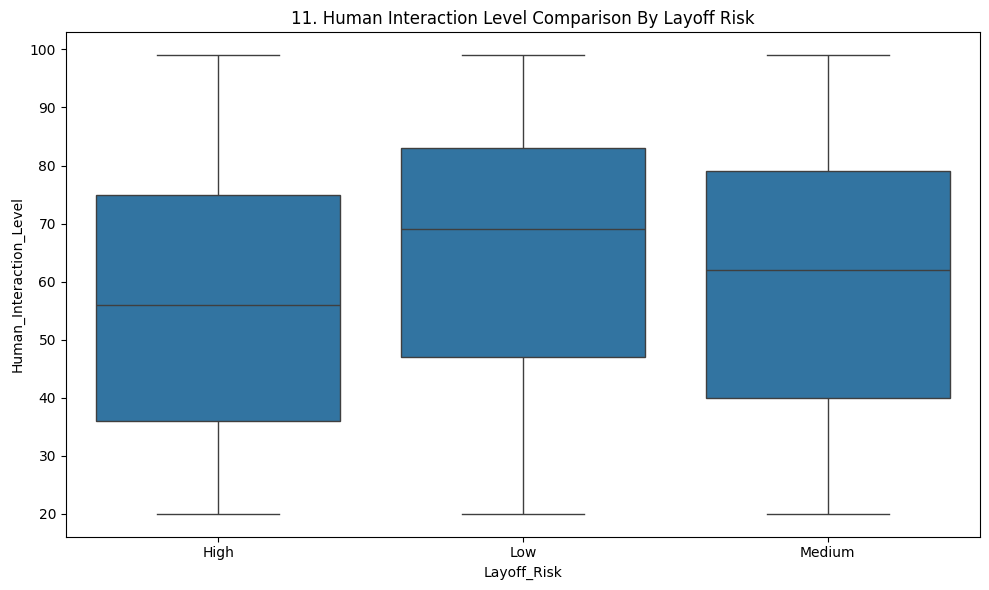

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Layoff_Risk', y='Human_Interaction_Level')
plt.title(f'{plot_no}. Human Interaction Level Comparison By Layoff Risk')
show_fig()
plot_no += 1

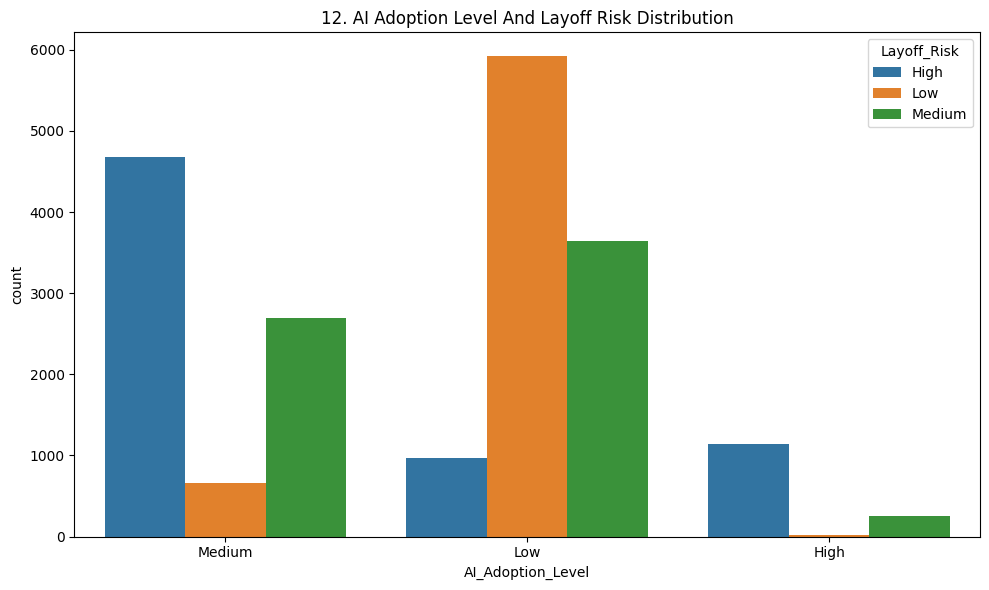

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='AI_Adoption_Level', hue='Layoff_Risk')
plt.title(f'{plot_no}. AI Adoption Level And Layoff Risk Distribution')
show_fig()
plot_no += 1

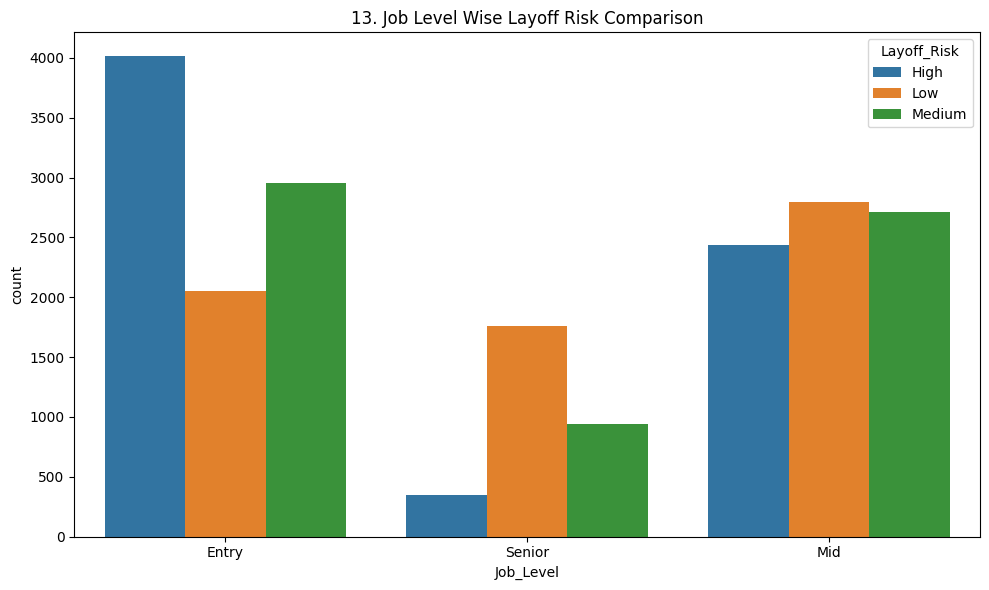

In [25]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Job_Level', hue='Layoff_Risk')
plt.title(f'{plot_no}. Job Level Wise Layoff Risk Comparison')
show_fig()
plot_no += 1

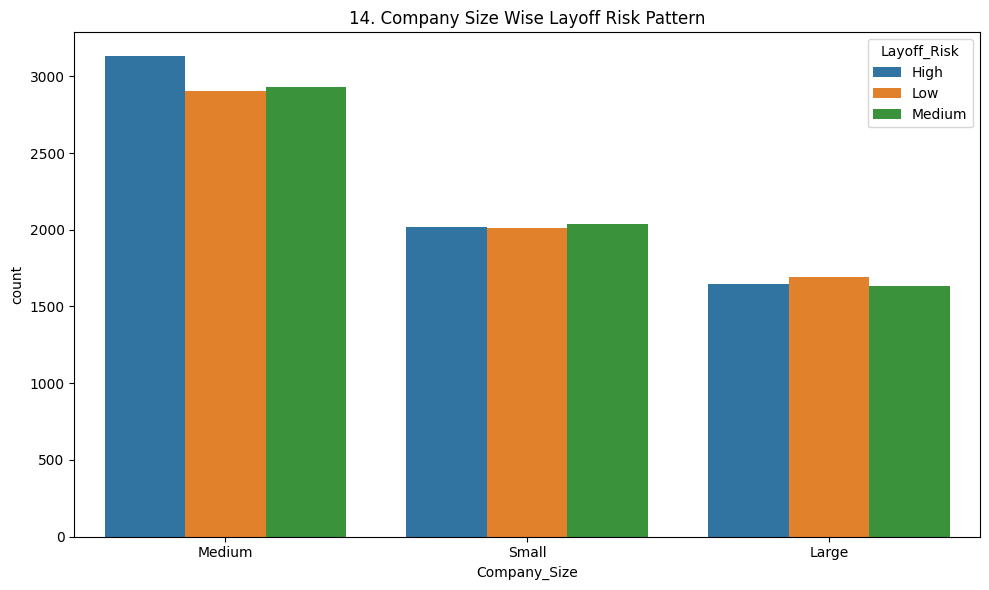

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Company_Size', hue='Layoff_Risk')
plt.title(f'{plot_no}. Company Size Wise Layoff Risk Pattern')
show_fig()
plot_no += 1

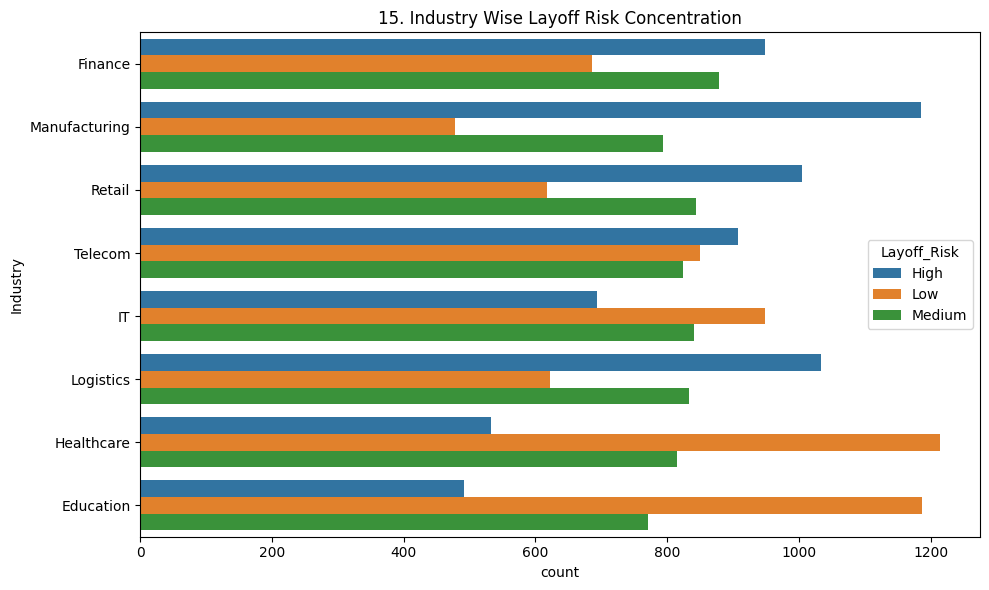

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Industry', hue='Layoff_Risk')
plt.title(f'{plot_no}. Industry Wise Layoff Risk Concentration')
show_fig()
plot_no += 1

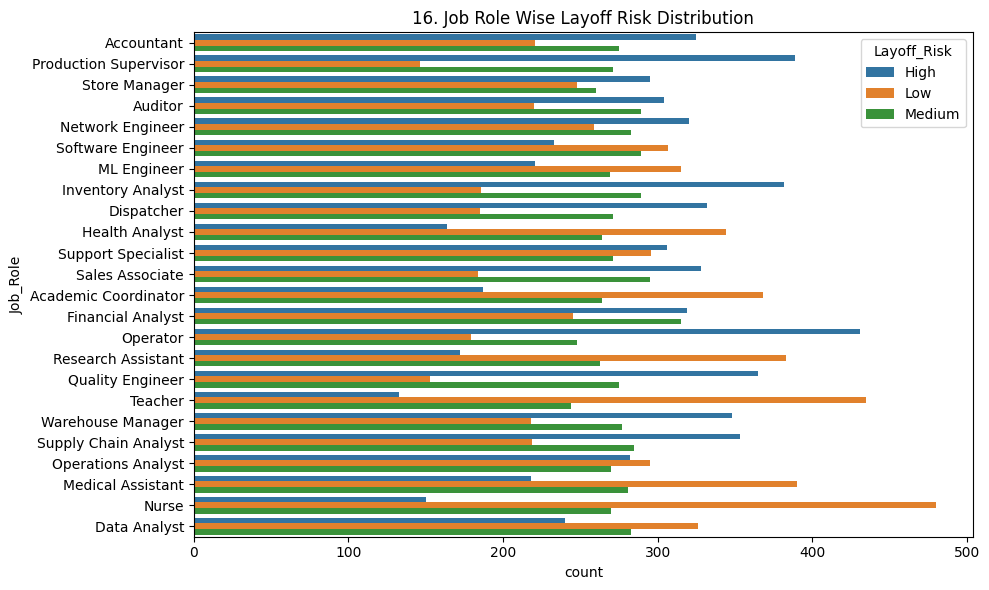

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Job_Role', hue='Layoff_Risk')
plt.title(f'{plot_no}. Job Role Wise Layoff Risk Distribution')
show_fig()
plot_no += 1

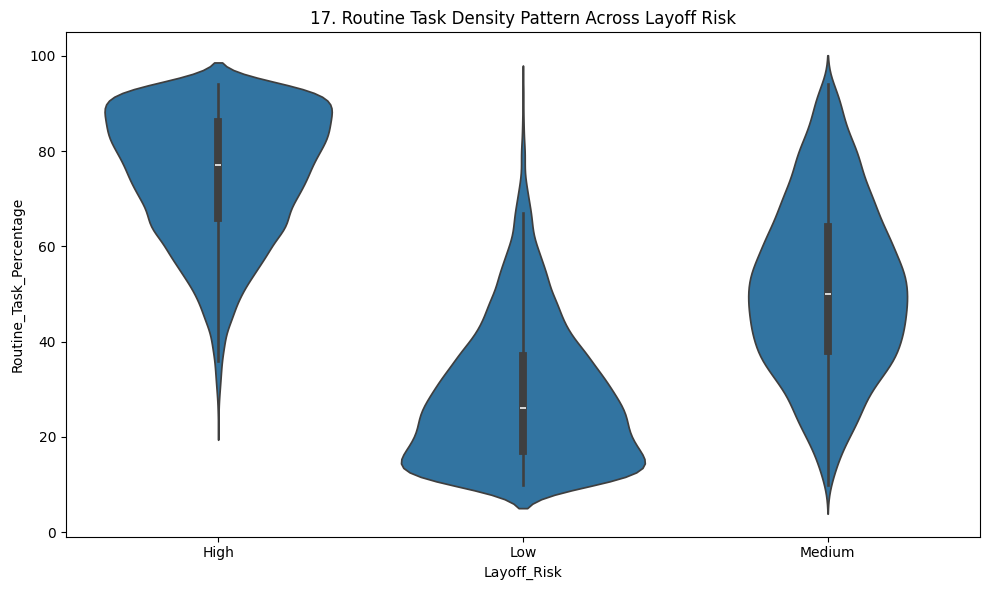

In [29]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Layoff_Risk', y='Routine_Task_Percentage')
plt.title(f'{plot_no}. Routine Task Density Pattern Across Layoff Risk')
show_fig()
plot_no += 1

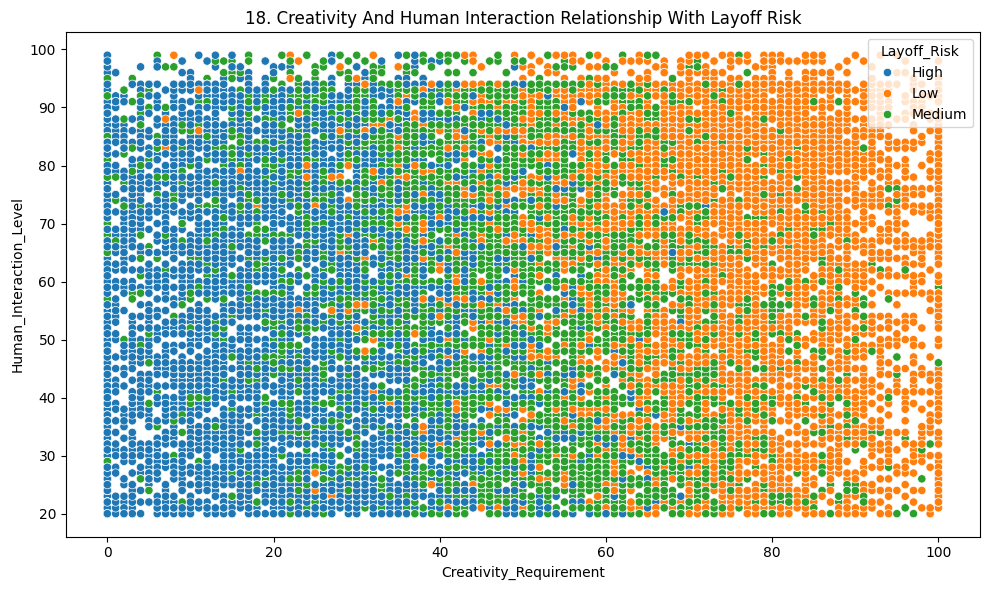

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Creativity_Requirement', y='Human_Interaction_Level', hue='Layoff_Risk')
plt.title(f'{plot_no}. Creativity And Human Interaction Relationship With Layoff Risk')
show_fig()
plot_no += 1

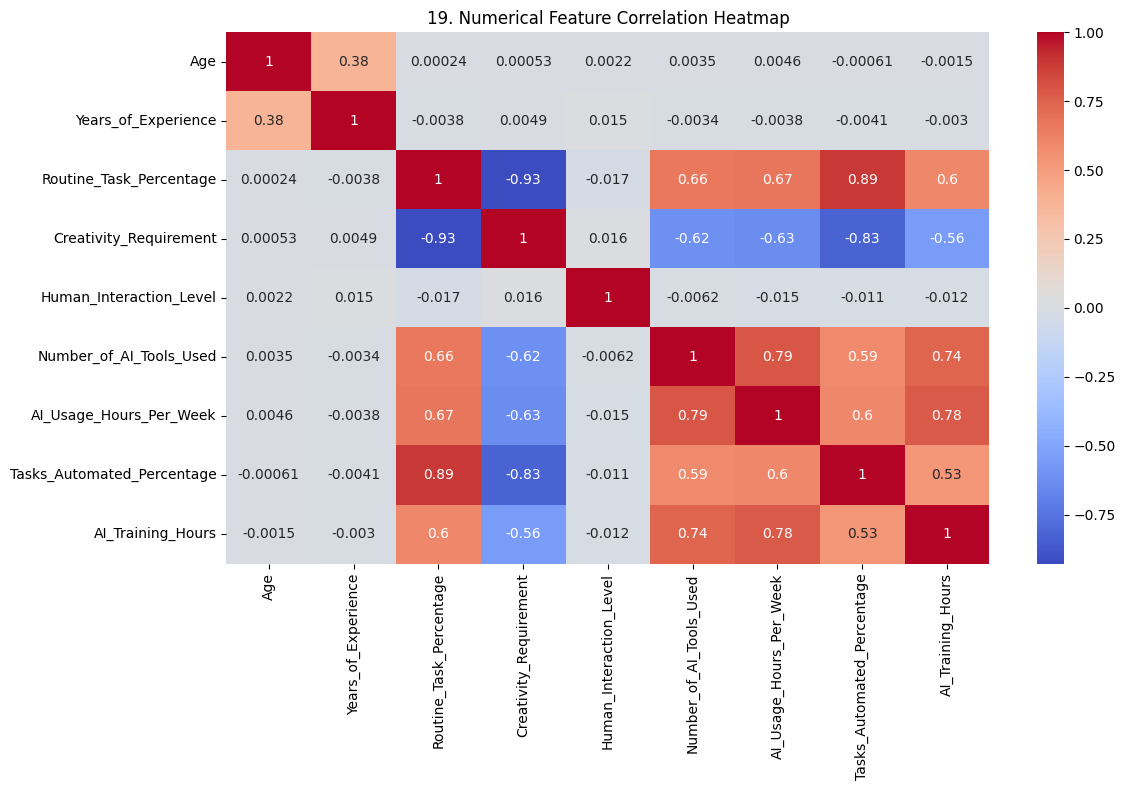

In [31]:
corr = df.select_dtypes(include='number').corr()
fig = plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Numerical Feature Correlation Heatmap')
show_fig()
plot_no += 1

# Model Training

## Separate input features and target column

In [32]:
X = df.drop('Layoff_Risk', axis=1)
y = df['Layoff_Risk']

## Encode target labels

In [33]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

## Select numeric and categorical columns

In [34]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

## Create preprocessing for numeric and categorical data

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

## Split data into training and testing parts

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

## Create supervised classification model

In [37]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

## Train the model

In [38]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Years_of_Experience', 'Routine_Task_Percentage',
       'Creativity_Requirement', 'Human_Interaction_Level',
       'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week',
       'Tasks_Automated_Percentage', 'AI_Training_Hours'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Education_Level', 'Industry', 'Job_Role', 'Company_Size', 'Job_Level',
       'AI_Adoption_Level'],
      dtype='object'))])),
                ('classifier',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=250,
                                            random_state=42))])

## Predict test data

In [39]:
y_pred = model.predict(X_test)

## Calculate model accuracy

In [40]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy Score:", round(accuracy * 100, 2), "%")

Model Accuracy Score: 92.42 %


## Print detailed classification report

In [41]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Classification Report:
              precision    recall  f1-score   support

        High       0.94      0.94      0.94      1360
         Low       0.95      0.94      0.95      1320
      Medium       0.88      0.90      0.89      1320

    accuracy                           0.92      4000
   macro avg       0.92      0.92      0.92      4000
weighted avg       0.92      0.92      0.92      4000



## Create confusion matrix


In [42]:
cm = confusion_matrix(y_test, y_pred)

## Plot confusion matrix

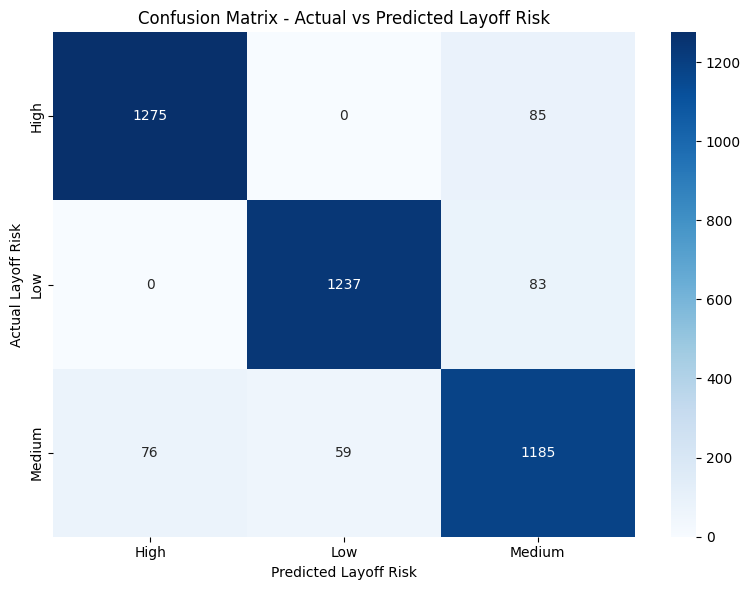

In [43]:
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Confusion Matrix - Actual vs Predicted Layoff Risk")
plt.xlabel("Predicted Layoff Risk")
plt.ylabel("Actual Layoff Risk")
plt.tight_layout()
plt.show()